In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [10]:
# Load the CSV
csv_path = "inference_results.csv"  # or your full path
df = pd.read_csv(csv_path)

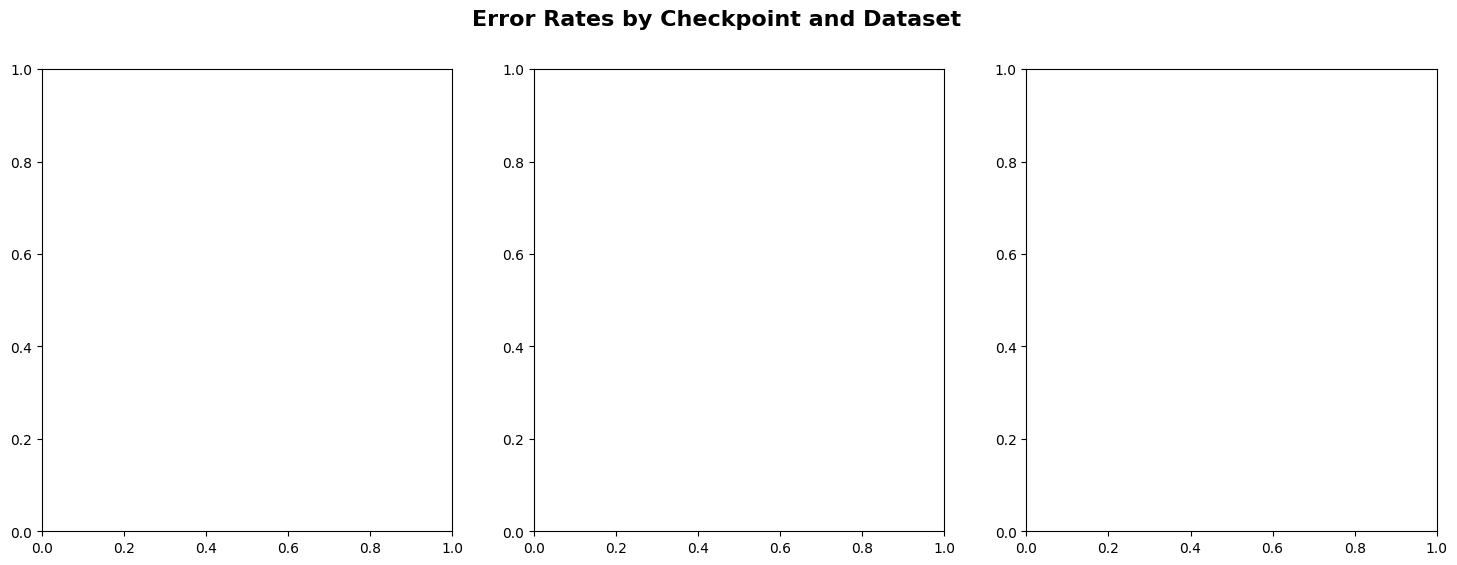

In [11]:
# Set up the figure with 3 subplots (one for each dataset)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Error Rates by Checkpoint and Dataset', fontsize=16, fontweight='bold')

# Dataset names
datasets = ['overall', 'kern', 'xmhm']
metrics = ['cer', 'ser', 'ler']
metric_labels = ['CER', 'SER', 'LER']

# Color scheme for the three metrics
colors = ['#2ecc71', '#e74c3c', '#3498db']  # Green, Red, Blue

# X-axis positions
x = np.arange(len(df))
width = 0.25  # Width of each bar

In [14]:
# Create a subplot for each dataset
# Create a subplot for each dataset
for idx in range(len(datasets)):
    ax = axes[idx]
    name, cer_col, ser_col, ler_col = datasets[idx]
    
    # Extract the three metrics for this dataset
    cer_data = df[cer_col]
    ser_data = df[ser_col]
    ler_data = df[ler_col]
    
    # Plot grouped bars
    ax.bar(x - width, cer_data, width, label='CER', color=colors[0], alpha=0.8)
    ax.bar(x, ser_data, width, label='SER', color=colors[1], alpha=0.8)
    ax.bar(x + width, ler_data, width, label='LER', color=colors[2], alpha=0.8)
    
    # Formatting
    ax.set_xlabel('Checkpoint', fontsize=12, fontweight='bold')
    ax.set_ylabel('Error Rate (%)', fontsize=12, fontweight='bold')
    ax.set_title(f'{name} Dataset', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(df['tokenizer_type'], rotation=45, ha='right')
    ax.legend()
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    
    # Add value labels on top of bars
    for i in range(len(df)):
        ax.text(i - width, cer_data.iloc[i] + 1, f'{cer_data.iloc[i]:.1f}', 
                ha='center', va='bottom', fontsize=7)
        ax.text(i, ser_data.iloc[i] + 1, f'{ser_data.iloc[i]:.1f}', 
                ha='center', va='bottom', fontsize=7)
        ax.text(i + width, ler_data.iloc[i] + 1, f'{ler_data.iloc[i]:.1f}', 
                ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig('inference_results_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

ValueError: too many values to unpack (expected 4)

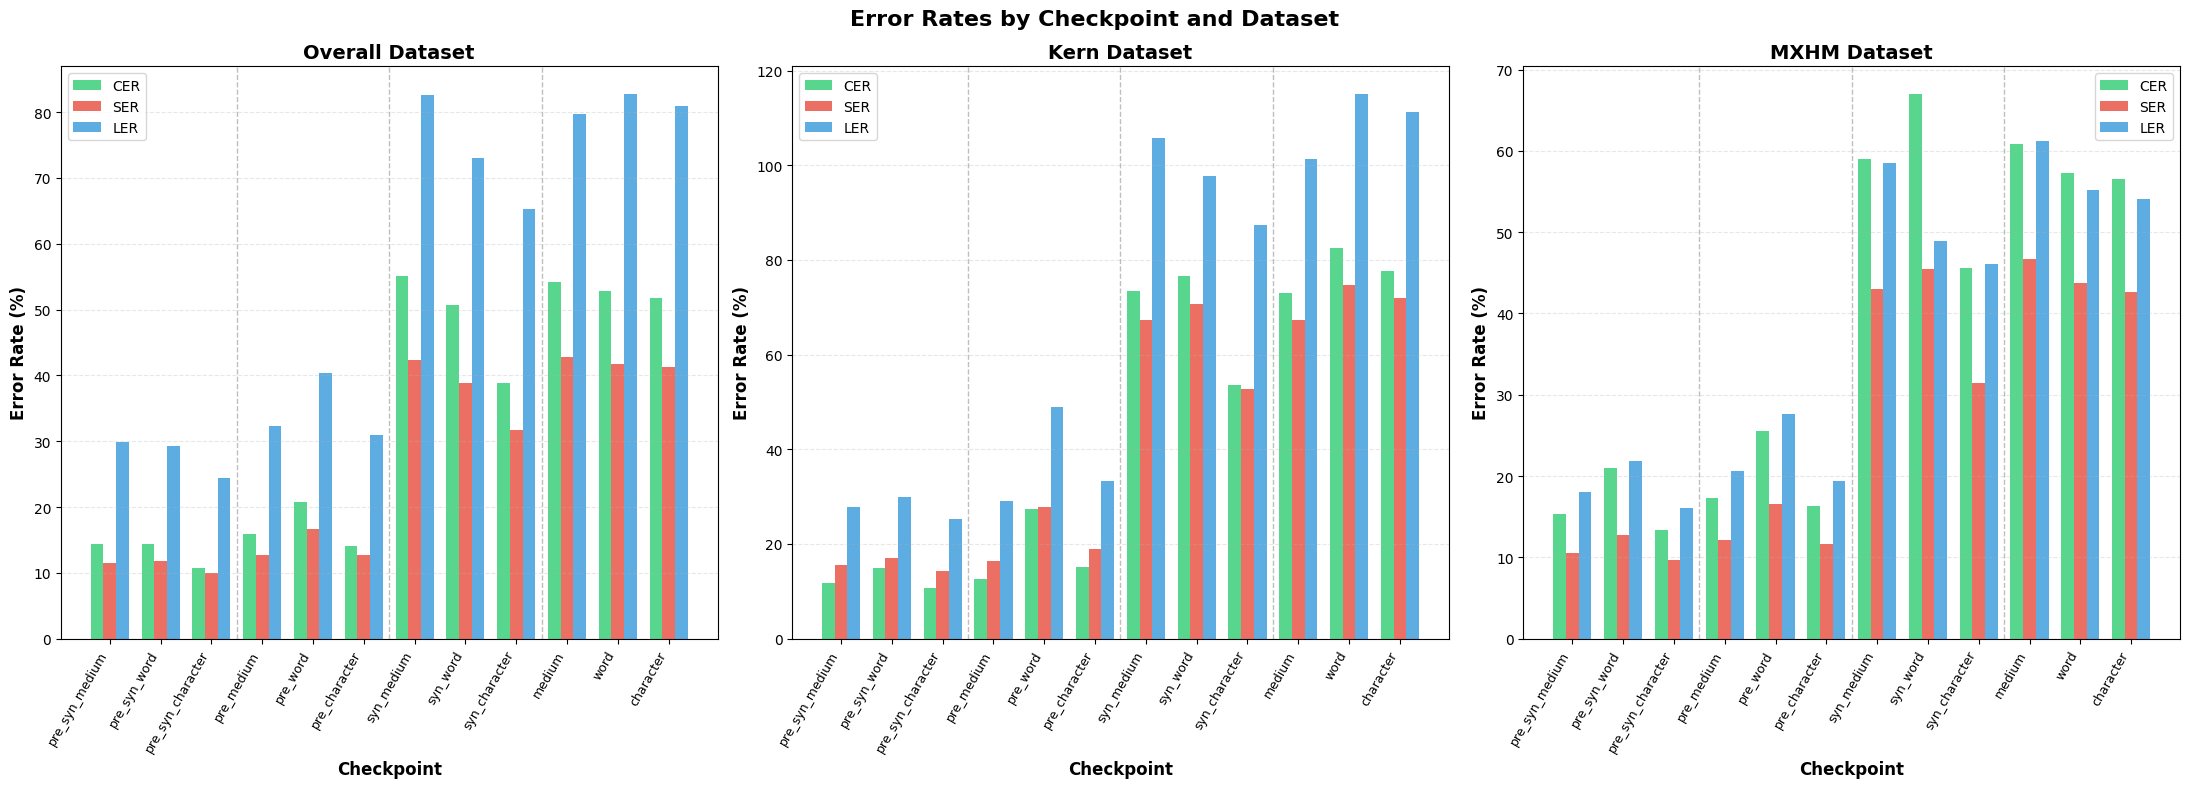

Visualization saved as 'inference_results_visualization.png'


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the CSV
csv_path = "fullpage_inference_results.csv"  # or your full path
df = pd.read_csv(csv_path)

# Define the desired order
order = [
    'smt_pre_syn_medium.ckpt',
    'smt_pre_syn_word.ckpt',
    'smt_pre_syn_character.ckpt',
    'smt_pre_medium.ckpt',
    'smt_pre_word.ckpt',
    'smt_pre_character.ckpt',
    'smt_syn_medium.ckpt',
    'smt_syn_word.ckpt',
    'smt_syn_character.ckpt',
    'smt_medium.ckpt',
    'smt_word.ckpt',
    'smt_character.ckpt'
]

# Reorder the dataframe according to the order list
df['checkpoint_name'] = pd.Categorical(df['checkpoint_name'], categories=order, ordered=True)
df = df.sort_values('checkpoint_name').reset_index(drop=True)

# Set up the figure with 3 subplots (one for each dataset)
fig, axes = plt.subplots(1, 3, figsize=(22, 8))
fig.suptitle('Error Rates by Checkpoint and Dataset', fontsize=16, fontweight='bold')

# Dataset configurations
datasets = [
    ('Overall', 'cer', 'ser', 'ler'),
    ('Kern', 'cer_kern', 'ser_kern', 'ler_kern'),
    ('MXHM', 'cer_mxhm', 'ser_mxhm', 'ler_mxhm')
]

# Color scheme for the three metrics
colors = ['#2ecc71', '#e74c3c', '#3498db']  # Green, Red, Blue

# X-axis positions
x = np.arange(len(df))
width = 0.25  # Width of each bar

# Create simplified checkpoint names (remove .ckpt extension and "smt_" prefix)
checkpoint_labels = [name.replace('.ckpt', '').replace('smt_', '') for name in df['checkpoint_name']]

# Create a subplot for each dataset
for idx in range(len(datasets)):
    ax = axes[idx]
    name, cer_col, ser_col, ler_col = datasets[idx]
    
    # Extract the three metrics for this dataset
    cer_data = df[cer_col]
    ser_data = df[ser_col]
    ler_data = df[ler_col]
    
    # Plot grouped bars
    ax.bar(x - width, cer_data, width, label='CER', color=colors[0], alpha=0.8)
    ax.bar(x, ser_data, width, label='SER', color=colors[1], alpha=0.8)
    ax.bar(x + width, ler_data, width, label='LER', color=colors[2], alpha=0.8)
    
    # Formatting
    ax.set_xlabel('Checkpoint', fontsize=12, fontweight='bold')
    ax.set_ylabel('Error Rate (%)', fontsize=12, fontweight='bold')
    ax.set_title(f'{name} Dataset', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(checkpoint_labels, rotation=60, ha='right', fontsize=9)
    ax.legend()
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    
    # Add vertical lines to separate groups
    ax.axvline(x=2.5, color='gray', linestyle='--', linewidth=1, alpha=0.5)
    ax.axvline(x=5.5, color='gray', linestyle='--', linewidth=1, alpha=0.5)
    ax.axvline(x=8.5, color='gray', linestyle='--', linewidth=1, alpha=0.5)

plt.tight_layout()
plt.savefig('inference_results_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

print("Visualization saved as 'inference_results_visualization.png'")